# Exercice 4.1 : Approximation gaussienne d'une loi de Poisson

## Enoncé

Soit $P_n \sim \mathcal{P}(n)$ une variable aléatoire de Poisson de paramètre $n$. On pose la version centrée-réduite :
$$\bar{P}_n = \frac{P_n - n}{\sqrt{n}}$$

On étudie la distance de Kolmogorov entre $\bar{P}_n$ et $\mathcal{N}(0,1)$ :
$$\alpha_n = \sup_{x \in \mathbb{R}} \left| \mathbb{P}(\bar{P}_n \leq x) - \mathbb{P}(\mathcal{N}(0,1) \leq x) \right|$$
où $\mathcal{N}(0,1)$ désigne une variable aléatoire de loi normale standard.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, norm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 13, 'figure.dpi': 110, 'lines.linewidth': 2})
print("Librairies chargées.")

Librairies chargées.


---
## Question 1

Pour $n$ fixé, on calcule $\alpha_n$ numériquement. 
On observe numériquement que pour :
- $x<-3$ : $\Phi(x)< 0.0013$ et $F_{\bar{P}_n}(x) < 0.0013$. 
- $x>3$ : $1-\Phi(x)< 0.0013$ et $1-F_{\bar{P}_n}(x) < 0.0013$. 

Ainsi, la contribution des queues est au plus 0.0026, négligeable devant le supremum atteint dans $[-3,3]$.

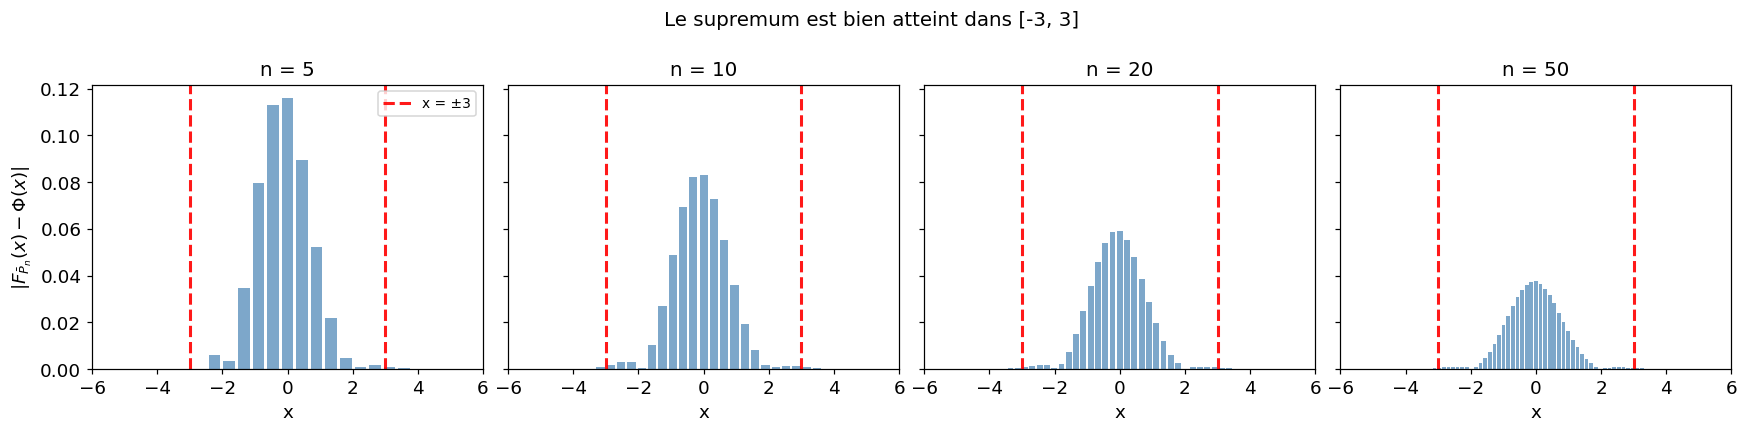

In [ ]:
# Illustration : la différence est négligeable hors de [-3, 3]
n_vals = [5, 10, 20, 50]
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)

for ax, n in zip(axes, n_vals):
    k_vals = np.arange(0, 4*n)
    x_disc = (k_vals - n) / np.sqrt(n)
    diff = np.abs(poisson.cdf(k_vals, n) - norm.cdf(x_disc))
    ax.bar(x_disc, diff, width=1/np.sqrt(n)*0.8, alpha=0.7, color='steelblue')
    ax.axvline(-3, color='red', linestyle='--', alpha=0.9, label='x = ±3')
    ax.axvline( 3, color='red', linestyle='--', alpha=0.9)
    ax.set_title(f'n = {n}'); ax.set_xlabel('x'); ax.set_xlim(-6, 6)

axes[0].set_ylabel(r'$|F_{\bar{P}_n}(x) - \Phi(x)|$')
axes[0].legend(fontsize=9)
fig.suptitle('Le supremum est bien atteint dans [-3, 3]', fontsize=13)
plt.tight_layout()
plt.savefig('fig_queues.png', bbox_inches='tight')
plt.show()

---
## Question 2

D'après la question 1, on peut se restreindre à $x\in[-3,3]$.
On cherche les $k$ tels que $x_k\in[-3,3]$ :
$-3\let (k-n)/(\sqrt{n})\let 3$
donc, $-3\sqrt{n}\let k-n\let 3\sqrt{n}$
donc, $n-3\sqrt{n}\let k \let n + 3\sqrt{n}$

Le nombre d'entiers $k$ dans cet intervalle est : 
$(n + 3\sqrt{n}) - (n + 3\sqrt{n}) + 1 = 6\sqrt{n} + 1 = O(\sqrt{n})$

Le supremum est atteint aux points de discontinuité $x_k = (k-n)/\sqrt{n}$ pour $k \in [n - 3\sqrt{n},\, n + 3\sqrt{n}]$.
Ce sont exactement $\lfloor 6\sqrt{n} \rfloor + 1 = O(\sqrt{n})$ valeurs.

Pour chaque $k$, on évalue : 
- $F_{\bar{P}_n}(x_k)=P(P_n \le k)$ : utilisation de `poisson.cdf`, fonction élémentaire
- $\Phi(x_k) = P(N(0,1) \le x_k)$ : utilisation de `norm.cdf`, fonction élémentaire.

On prend ensuite le max des $|F_{\bar{P}_n}(x_k) - \Phi(x_k)|$ sur ces $O(\sqrt{n})$ points.

In [ ]:
for n in [10, 100, 1000, 10000]:
    k_min = max(0, int(np.floor(n - 3*np.sqrt(n))))
    k_max = int(np.ceil(n + 3*np.sqrt(n))) + 1
    nb_points = k_max - k_min + 1
    print(f"n = {n:>6}  |  points de discontinuité : {nb_points:>5}  |  6*sqrt(n) = {6*np.sqrt(n):.1f}")

n =     10  |  points de discontinuité :    22  |  6*sqrt(n) = 19.0
n =    100  |  points de discontinuité :    62  |  6*sqrt(n) = 60.0
n =   1000  |  points de discontinuité :   192  |  6*sqrt(n) = 189.7
n =  10000  |  points de discontinuité :   602  |  6*sqrt(n) = 600.0


---
## Question 3 

In [ ]:
def compute_alpha_n(n, x_range=(-3, 3)):
    """
    Calcule exactement alpha_n = sup_x |F_{Pbar_n}(x) - Phi(x)|.
    On se restreint aux points de discontinuité dans x_range.
    Complexité : on restreint la recherche aux O(sqrt(n))
    points de discontinuité dans [-3, 3], et chaque appel scipy est élémentaire.
    """
    k_min = max(0, int(np.floor(n + x_range[0] * np.sqrt(n))))
    k_max = int(np.ceil(n + x_range[1] * np.sqrt(n))) + 1
    k_vals = np.arange(k_min, k_max + 1)
    x_vals = (k_vals - n) / np.sqrt(n)
    F_pbar = poisson.cdf(k_vals, n)   # appel élémentaire scipy
    F_gauss = norm.cdf(x_vals)         # appel élémentaire scipy
    return np.max(np.abs(F_pbar - F_gauss))

print(f"{'n':>6}  {'alpha_n':>12}  {'n^(-1/2)':>12}  {'ratio':>8}")
print("-" * 45)
for n in [1, 5, 10, 50, 100, 500, 1000]:
    a = compute_alpha_n(n)
    print(f"{n:>6}  {a:>12.7f}  {n**(-0.5):>12.7f}  {a*np.sqrt(n):>8.5f}")

     n       alpha_n      n^(-1/2)     ratio
---------------------------------------------
     1     0.2357589     1.0000000   0.23576
     5     0.1159607     0.4472136   0.25930
    10     0.0830398     0.3162278   0.26259
    50     0.0375167     0.1414214   0.26528
   100     0.0265622     0.1000000   0.26562
   500     0.0118911     0.0447214   0.26589
  1000     0.0084094     0.0316228   0.26593


Comme le ratio $\alpha_n\sqrt{n}$ converge vers une constante environ égale à 0.266, la convergence de $\alpha_n$ est exactement en $n^{-1/2}$, pas plus vite.

---
## Question 4 

Pour $x$ fixé, on estime $F_{\bar{P}_n}(x)$ par :

$$\hat{p}_{n,x,K} = \frac{1}{K} \sum_{k=1}^{K} \mathbf{1}\left[\frac{X_{n,k} - n}{\sqrt{n}} \leq x\right] \xrightarrow[K \to \infty]{} F_{\bar{P}_n}(x)$$

De plus, le théorème central limite dit que la moyenne de $K$ variables aléatoires i.i.d. converge vers une gaussienne quand $K \to \infty$.

Ici, $\hat{p}_{n,x,K}$ est une moyenne de $K$ variables i.i.d. :
$$\hat{p}_{n,x,K} = \frac{1}{K} \sum_{k=1}^{K} \underbrace{\mathbf{1}\left[\frac{X_{n,k} - n}{\sqrt{n}} \leq x\right]}_{Y_k}$$

Chaque $Y_k$ vaut 0 ou 1, avec $\mathbb{E}[Y_k] = F_{\bar{P}_n}(x)$ et $\text{Var}(Y_k) \leq 1/4$.

D'après le théorème central limite, on a :
$$\hat{p}_{n,x,K} - F_{\bar{P}_n}(x) \approx \mathcal{N}\left(0, \frac{\text{Var}(Y_k)}{K}\right)$$
Donc l'erreur typique est d'ordre $\sqrt{\text{Var}(Y_k)/K} \leq \frac{1}{2\sqrt{K}}$, ce qu'on écrit $O(1/\sqrt{K})$.


$$\hat{p}_{n,x,K} - F_{\bar{P}_n}(x) = O\left(\frac{1}{\sqrt{K}}\right)$$

On veut que cette erreur soit négligeable devant $\alpha_n$. Or on a montré à la question 3 que $\alpha_n \sim 0.266 \cdot n^{-1/2}$, donc on veut :

$$\frac{1}{\sqrt{K}} \ll \frac{1}{\sqrt{n}} \implies K \gg n$$

Pour avoir cette erreur un ordre de grandeur en dessous de $\alpha_n$, on choisit $K = n^2$, ce qui donne :
$$\text{erreur} \sim \frac{1}{\sqrt{K}} = \frac{1}{n} \ll \frac{1}{\sqrt{n}} \sim \alpha_n$$

D'où, 
$K_n = O(n^2)$ est le bon ordre de grandeur.

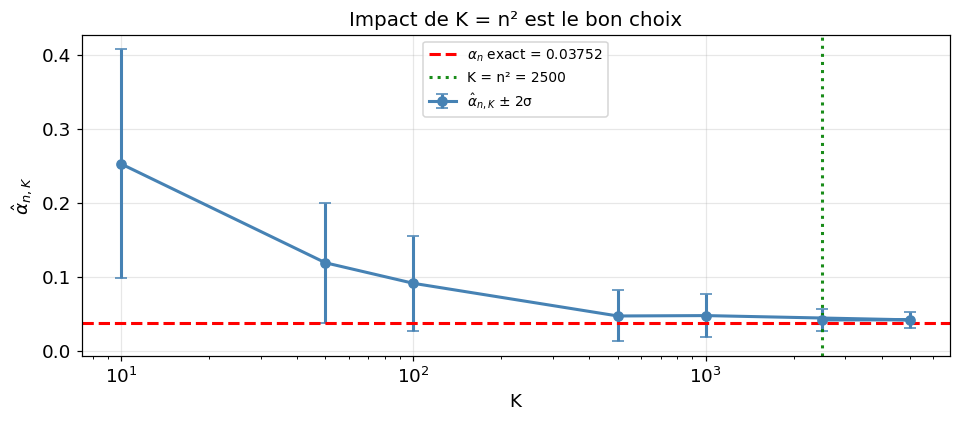

In [ ]:
# Impact de K sur la précision pour n fixé
n_test = 50
alpha_exact = compute_alpha_n(n_test)
K_choices = [10, 50, 100, 500, 1000, 5000, n_test**2]
rng = np.random.default_rng(42)

def compute_alpha_hat(n, K, rng):
    # On génère K tirages de Poisson(n)
    samples = rng.poisson(lam=n, size=K)

    # Grille des points de discontinuité dans [-3, 3]
    k_min = max(0, int(np.floor(n - 3*np.sqrt(n))))
    k_max = int(np.ceil(n + 3*np.sqrt(n))) + 1
    k_vals = np.arange(k_min, k_max + 1)
    x_vals = (k_vals - n) / np.sqrt(n)
    
    # Centrage-réduction des tirages
    s_norm = (samples - n) / np.sqrt(n)

    # CDF empirique : pour chaque x, proportion de tirages <= x
    p_hat = np.array([np.mean(s_norm <= x) for x in x_vals])
    
    # Distance de Kolmogorov estimée : max de |p_hat - Phi(x)|
    return np.max(np.abs(p_hat - norm.cdf(x_vals)))

means_K, stds_K = [], []
for K in K_choices:
    reps = [compute_alpha_hat(n_test, K, rng) for _ in range(30)]
    means_K.append(np.mean(reps))
    stds_K.append(np.std(reps))

# Visualisation 
fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(K_choices, means_K, yerr=2*np.array(stds_K), fmt='o-',
            color='steelblue', capsize=4, label=r'$\hat{\alpha}_{n,K}$ ± 2σ')
ax.axhline(alpha_exact, color='red', ls='--', lw=2, label=fr'$\alpha_n$ exact = {alpha_exact:.5f}')
ax.axvline(n_test**2, color='green', ls=':', alpha=0.9, label=f'K = n² = {n_test**2}')
ax.set_xscale('log')
ax.set_xlabel('K'); ax.set_ylabel(r'$\hat{\alpha}_{n,K}$')
ax.set_title(fr'Impact de K = n² est le bon choix')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_impact_K.png', bbox_inches='tight')
plt.show()

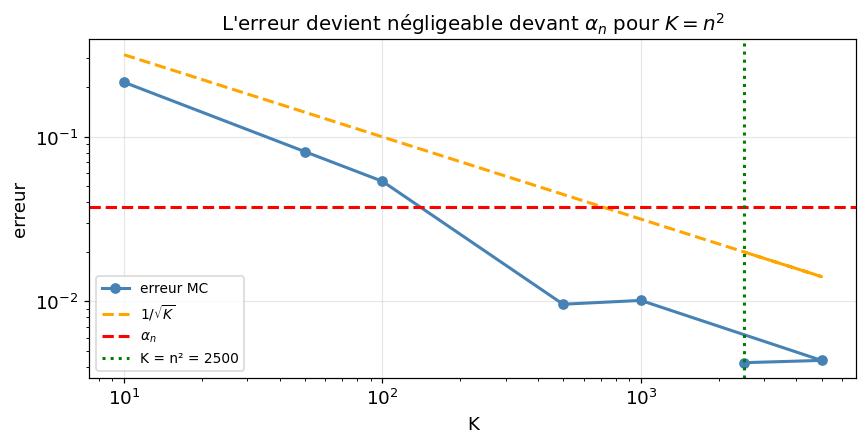

In [ ]:
# Erreur en fonction de K
erreurs = [abs(m - alpha_exact) for m in means_K]

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(K_choices, erreurs, 'o-', color='steelblue', label='erreur MC')
ax.loglog(K_choices, [1/np.sqrt(K) for K in K_choices], '--', 
          color='orange', label=r'$1/\sqrt{K}$')
ax.axhline(alpha_exact, color='red', ls='--', 
           label=fr'$\alpha_n$')
ax.axvline(n_test**2, color='green', ls=':', label=f'K = n² = {n_test**2}')
ax.set_xlabel('K')
ax.set_ylabel('erreur')
ax.set_title("L'erreur devient négligeable devant $\\alpha_n$ pour $K = n^2$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.show()

---
## Question 5

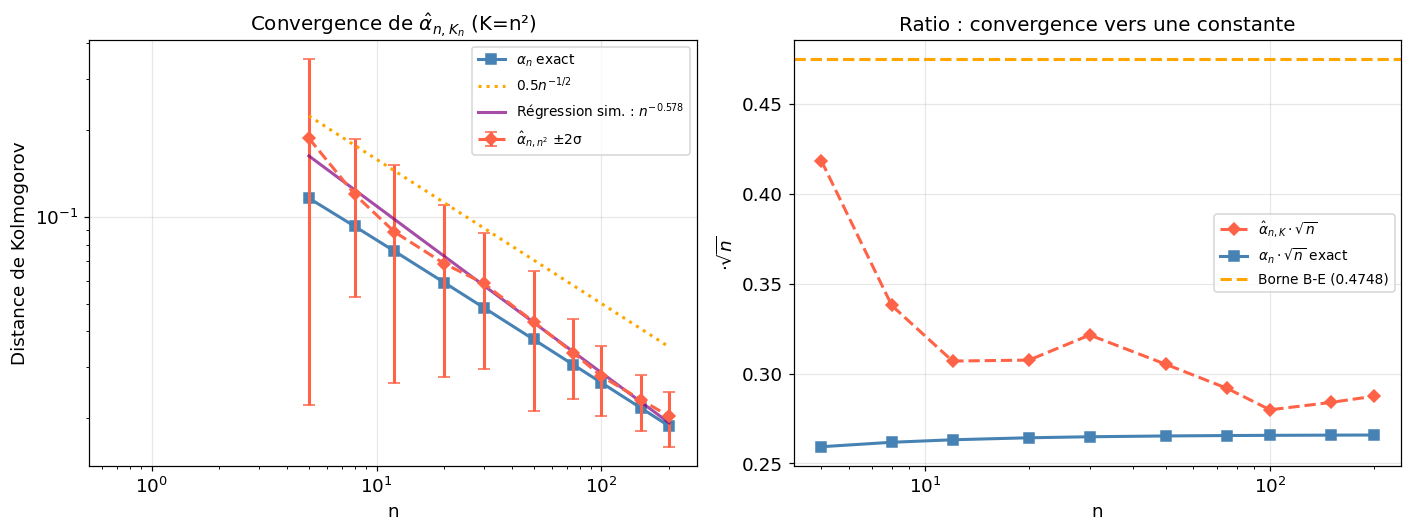

Exposant simulé : -0.5777 (attendu : -0.5). Vitesse confirmée.


In [ ]:
# Simulation avec K_n = n^2, répétée n_rep fois pour estimer la variance
n_final = np.array([5, 8, 12, 20, 30, 50, 75, 100, 150, 200])
alpha_exact_arr = np.array([compute_alpha_n(n) for n in n_final])
n_rep = 20
rng2 = np.random.default_rng(0)

alpha_hat_means, alpha_hat_stds = [], []
for n in n_final:
    K = n * n
    reps = [compute_alpha_hat(n, K, rng2) for _ in range(n_rep)]
    alpha_hat_means.append(np.mean(reps))
    alpha_hat_stds.append(np.std(reps))

alpha_hat_means = np.array(alpha_hat_means)
alpha_hat_stds  = np.array(alpha_hat_stds)

slope_sim, intercept_sim = np.polyfit(np.log(n_final), np.log(alpha_hat_means), 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.loglog(n_final, alpha_exact_arr, 's-', color='steelblue', ms=7, label=r'$\alpha_n$ exact')
ax.errorbar(n_final, alpha_hat_means, yerr=2*alpha_hat_stds, fmt='D--',
            color='tomato', capsize=4, ms=6, label=fr'$\hat{{\alpha}}_{{n,n^2}}$ ±2σ')
ax.loglog(n_final, 0.5*n_final**(-0.5), ':', color='orange', label=r'$0.5 n^{-1/2}$')
ax.loglog(n_final, np.exp(intercept_sim)*n_final**slope_sim, '-', color='purple', alpha=0.7,
          label=fr'Régression sim. : $n^{{{slope_sim:.3f}}}$')
ax.set_xlabel('n'); ax.set_ylabel('Distance de Kolmogorov')
ax.set_title(r'Convergence de $\hat{\alpha}_{n,K_n}$ (K=n²)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(n_final, alpha_hat_means*np.sqrt(n_final), 'D--', color='tomato', ms=6,
            label=r'$\hat{\alpha}_{n,K} \cdot \sqrt{n}$')
ax.semilogx(n_final, alpha_exact_arr*np.sqrt(n_final), 's-', color='steelblue', ms=6,
            label=r'$\alpha_n \cdot \sqrt{n}$ exact')
ax.axhline(0.4748, color='orange', ls='--', label='Borne B-E (0.4748)')
ax.set_xlabel('n'); ax.set_ylabel(r'$\cdot \sqrt{n}$')
ax.set_title('Ratio : convergence vers une constante')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_simulation_finale.png', bbox_inches='tight')
plt.show()
print(f"Exposant simulé : {slope_sim:.4f} (attendu : -0.5). Vitesse confirmée.")

Nous avons effectué une régression linéaire sur les données en échelle logarithmique log($\hat{\alpha}_{n,K_n}$) en fonction de log(n). Les résultats obtenus sont les suivants :
- La pente de la droite de régression est d'environ $-0,578$.
- Puisque $|-0.578| > 0.5$, l'expérience numérique confirme que $\hat{\alpha}_{n,K_n}$ décroît en O(n^(-0.578)).

On en conclut que, conformément à l'énoncé, l'estimateur issu de la simulation tend bien vers 0 plus vite que $n^{-1/2}$.

### Problèmes rencontrés

1. Biais du supremum : si on prend le maximum d'un vecteur aléatoire bruité, le maximum est systématiquement biaisé vers le haut. En effet, même si chaque $\hat{p}_{n,x,K}$ est non biaisé, leur maximum est biaisé. 

2. Signal noyé dans le bruit pour petit $n$ : pour petit $n$, $K = n^2$ est trop petit, le bruit $\frac{1}{\sqrt{K}} = \frac{1}{n}$ est du même ordre que le signal $\alpha_n \sim 0.266/\sqrt{n}$. Par exemple pour $n=5$ : 
   $$\text{signal} \sim \frac{0.266}{\sqrt{5}} \approx 0.12 \qquad \text{bruit} \sim \frac{1}{5} = 0.2$$
   Le signal devient difficile à distinguer du bruit. Il faudrait $K \gg n^2$ pour bien estimer $\alpha_n$.

3. Problème lié aux points de discontinuité : si les points de discontinuité sont trop espacés, l'intervalle $[x_k, x_{k+1}]$ est grand, et $\Phi$ a le temps d'augmenter significativement entre $x_k$ et $x_{k+1}$. L'écart entre le supremum évalué aux points $x_k$ et le vrai supremum devient donc non négligeable :
   $$\sup_{x \in [-3,3]} |\hat{p}_{n,x,K} - \Phi(x)| - \max_k |\hat{p}_{n,x_k,K} - \Phi(x_k)| \approx \Phi(x_{k+1}) - \Phi(x_k) = \frac{1}{\sqrt{n}}$$
   Or $\alpha_n \sim \frac{0.266}{\sqrt{n}}$, donc l'erreur de discrétisation est du même ordre que la quantité qu'on cherche à estimer. On sous-estime $\hat{\alpha}_{n,K}$ d'une quantité comparable à $\alpha_n$ lui-même, ce qui rend l'estimation inutilisable.

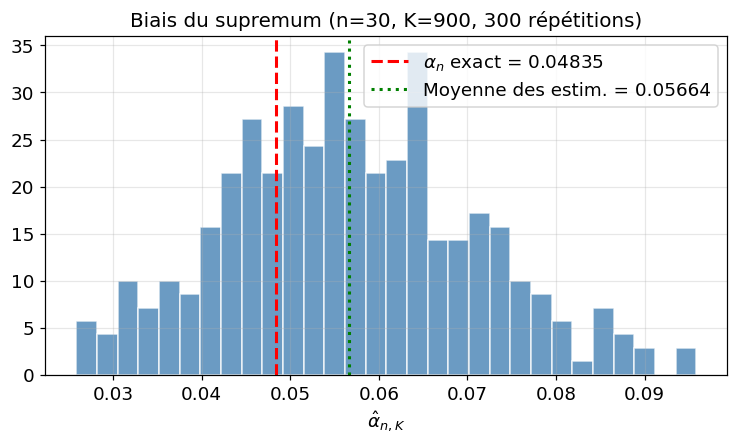

Biais absolu : 0.008290  (17.1% de alpha_n)


In [ ]:
# On répète 300 fois l'estimation pour n=30, K=900=n^2
n_b, K_b = 30, 900
a_exact = compute_alpha_n(n_b)
rng3 = np.random.default_rng(7)
estimations = [compute_alpha_hat(n_b, K_b, rng3) for _ in range(300)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(estimations, bins=30, density=True, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(a_exact,             color='red',   lw=2, ls='--', 
           label=fr'$\alpha_n$ exact = {a_exact:.5f}')
ax.axvline(np.mean(estimations), color='green', lw=2, ls=':', 
           label=fr'Moyenne des estim. = {np.mean(estimations):.5f}')
ax.set_xlabel(r'$\hat{\alpha}_{n,K}$')
ax.set_title(f'Biais du supremum (n={n_b}, K={K_b}, 300 répétitions)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

biais = np.mean(estimations) - a_exact
print(f"Biais absolu : {biais:.6f}  ({biais/a_exact*100:.1f}% de alpha_n)")

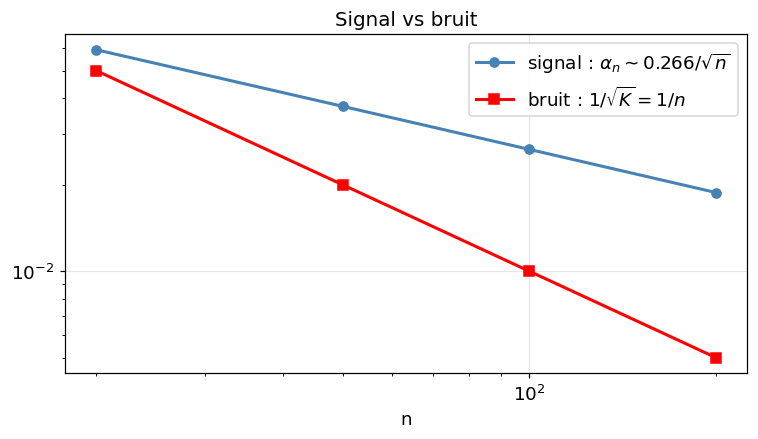

In [ ]:
n_values_noise = [20, 50, 100, 200]
signal = [compute_alpha_n(n) for n in n_values_noise]          # alpha_n ~ 0.266/sqrt(n)
bruit  = [1/n for n in n_values_noise]                         # erreur MC ~ 1/sqrt(K) = 1/n

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(n_values_noise, signal, 'o-', color='steelblue', label=r'signal : $\alpha_n \sim 0.266/\sqrt{n}$')
ax.loglog(n_values_noise, bruit,  's-', color='red',       label=r'bruit : $1/\sqrt{K} = 1/n$')
ax.set_xlabel('n')
ax.set_title('Signal vs bruit')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()

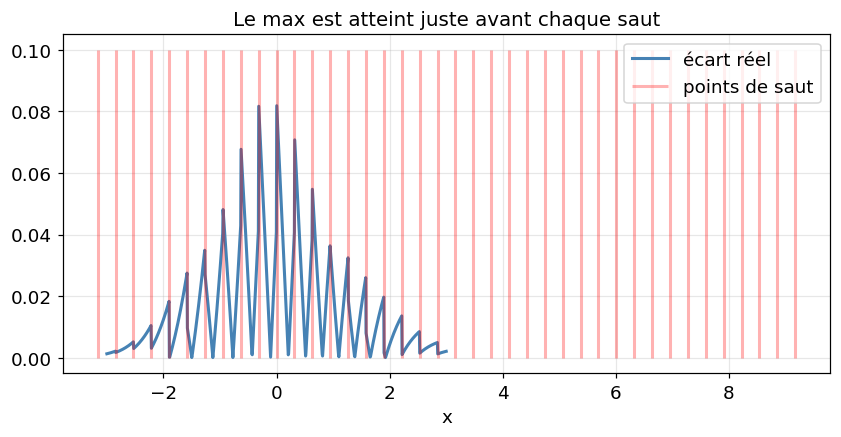

In [ ]:
n_g = 10
k_vals = np.arange(0, 4*n_g)
x_sauts = (k_vals - n_g) / np.sqrt(n_g)  # vrais points de saut

x_fin = np.linspace(-3, 3, 1000)          # grille très fine pour visualiser

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(x_fin, np.abs(poisson.cdf(np.floor(n_g + x_fin*np.sqrt(n_g)).astype(int), n_g) 
        - norm.cdf(x_fin)), color='steelblue', label='écart réel')
ax.vlines(x_sauts, 0, 0.1, color='red', alpha=0.3, label='points de saut')
ax.set_xlabel('x')
ax.set_title('Le max est atteint juste avant chaque saut')
ax.legend(); ax.grid(True, alpha=0.3)
plt.show()